In [ ]:
# # Clasificador binario de imágenes con EfficientNet-B0
#
# Caso: detectar datos de contacto en imágenes de publicaciones de e-commerce.
#
# **Este notebook entrena un baseline de CLASIFICACIÓN binaria** (imagen tiene/no tiene
# datos de contacto). Se compara contra el detector YOLOv8 entrenado en `tp_final.ipynb`,
# que hace **detección multi-clase + OCR** sobre las mismas imágenes.
#
# Para el paper IEEE las dos métricas comparables son `precision / recall / F1` a
# nivel imagen sobre el mismo `test.csv`.
#
# **Dataset esperado (mismo que tp_final.ipynb):**
#
# ```text
# dataset_imagenes/
# ├── train/
# │   ├── images/
# │   └── train.csv   (image_path, label, image_url)
# └── test/
#     ├── images/
#     └── test.csv
# ```
#
# **CSV esperado:** las columnas mínimas son `image_path` y `label`. El path puede
# ser relativo a la raíz del dataset (`train/images/xxx.jpg`) o al split
# (`images/xxx.jpg`); el código resuelve ambos casos.


In [1]:
# ## 1. Imports

import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

import matplotlib.pyplot as plt


In [2]:
# ## 2. Configuración general
#
# Ajustar principalmente:
#
# - `IMG_SIZE`: 384 para la corrida seria; 224 para prueba rápida.
# - `BATCH_SIZE`: si hay error de memoria, bajar a 16.
# - `NUM_EPOCHS`: 6 es el default — subir a 12-20 si la GPU lo permite.


In [3]:
SEED = 42
IMG_SIZE = 384
BATCH_SIZE = 32
NUM_EPOCHS = 6
LR = 5e-5
# num_workers > 0 hace que la DataLoader use multiprocessing.
# En Windows + Jupyter eso usa spawn() y suele colgar o andar más lento;
# en Linux/Mac (fork) acelera. Auto-ajustamos por OS.
NUM_WORKERS = 0 if os.name == "nt" else 2
VAL_SIZE = 0.15
EARLY_STOPPING_PATIENCE = 2
MIN_PRECISION_FOR_THRESHOLD = 0.70


# --- Paths LOCALES (no Colab) ---------------------------------------------------
# PROJECT_ROOT se autodetecta desde el CWD: corré el notebook desde la raíz del repo
# (donde está `dataset_imagenes/`).
PROJECT_ROOT = Path.cwd()
DATASET_DIR = PROJECT_ROOT / "dataset_imagenes"
OUTPUT_DIR = PROJECT_ROOT / "work" / "efficientnet_b0"


# --- Device selection: CUDA (NVIDIA) > MPS (Apple Silicon) > CPU --------------
def pick_device():
    if torch.cuda.is_available():
        return torch.device("cuda:0")
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


DEVICE = pick_device()
print("Device:", DEVICE)

# pin_memory solo tiene sentido en CUDA (acelera transferencia CPU->GPU)
PIN_MEMORY = DEVICE.type == "cuda"


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True


set_seed(SEED)


Device: cuda:0


In [4]:
# ## 3. Validar dataset local y crear OUTPUT_DIR
#
# (Reemplaza el mount de Google Drive del notebook original.)

if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"No se encontró el dataset en {DATASET_DIR}. "
        f"Asegurate de correr el notebook desde la raíz del repo (donde vive `dataset_imagenes/`)."
    )

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_DIR :", DATASET_DIR)
print("OUTPUT_DIR  :", OUTPUT_DIR)
print()
print("Contenido dataset:")
print(list(DATASET_DIR.iterdir()))


PROJECT_ROOT: C:\git\tp_vp2
DATASET_DIR : C:\git\tp_vp2\dataset_imagenes
OUTPUT_DIR  : C:\git\tp_vp2\work\efficientnet_b0

Contenido dataset:
[WindowsPath('C:/git/tp_vp2/dataset_imagenes/test'), WindowsPath('C:/git/tp_vp2/dataset_imagenes/train')]


In [5]:
# ## 4. Revisión rápida de CSVs

train_csv = DATASET_DIR / "train" / "train.csv"
test_csv = DATASET_DIR / "test" / "test.csv"

train_full_df = pd.read_csv(train_csv).reset_index(drop=True)
test_df = pd.read_csv(test_csv).reset_index(drop=True)

print("Train original:", train_full_df.shape)
display(train_full_df.head())

print("Test:", test_df.shape)
display(test_df.head())

print("Distribución train original:")
display(pd.concat([
    train_full_df["label"].value_counts().rename("count"),
    train_full_df["label"].value_counts(normalize=True).rename("proportion"),
], axis=1))

print("Distribución test:")
display(pd.concat([
    test_df["label"].value_counts().rename("count"),
    test_df["label"].value_counts(normalize=True).rename("proportion"),
], axis=1))

Train original: (10000, 3)


,image_path,label,image_url
0,train/images/train_000000.jpg,0,https://http2.mlstatic.com/D_602260-MLB8344881...
1,train/images/train_000001.jpg,0,https://http2.mlstatic.com/D_696827-MLB7188663...
2,train/images/train_000002.jpg,1,https://http2.mlstatic.com/D_973064-CBT7864421...
3,train/images/train_000003.jpg,0,https://http2.mlstatic.com/D_765627-MLB7444507...
4,train/images/train_000004.jpg,0,https://http2.mlstatic.com/D_821121-MLB4937902...


Test: (3000, 3)


,image_path,label,image_url
0,test/images/test_000000.jpg,0,https://http2.mlstatic.com/D_996681-MLA1007825...
1,test/images/test_000001.jpg,0,https://http2.mlstatic.com/D_832062-MLC7437135...
2,test/images/test_000002.jpg,0,https://http2.mlstatic.com/D_991225-MLB9807561...
3,test/images/test_000003.jpg,0,https://http2.mlstatic.com/D_876523-MLB7015732...
4,test/images/test_000004.jpg,0,https://http2.mlstatic.com/D_916251-MLB8911838...


Distribución train original:


,count,proportion
label,,
0,7000,0.7
1,3000,0.3


Distribución test:


,count,proportion
label,,
0,2907,0.969
1,93,0.031


In [6]:
# ## 5. Crear split `train` / `val` desde el train original
#
# Se mantiene intacto el test para evaluación final.

train_idx, val_idx = train_test_split(
    np.arange(len(train_full_df)),
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=train_full_df["label"],
)

print("Split interno:")
print("train interno:", len(train_idx))
print("val interno:", len(val_idx))

print("Distribución train interno:")
display(pd.concat([
    train_full_df.iloc[train_idx]["label"].value_counts().rename("count"),
    train_full_df.iloc[train_idx]["label"].value_counts(normalize=True).rename("proportion"),
], axis=1))

print("Distribución val interno:")
display(pd.concat([
    train_full_df.iloc[val_idx]["label"].value_counts().rename("count"),
    train_full_df.iloc[val_idx]["label"].value_counts(normalize=True).rename("proportion"),
], axis=1))


Split interno:
train interno: 8500
val interno: 1500
Distribución train interno:


,count,proportion
label,,
0,5950,0.7
1,2550,0.3


Distribución val interno:


,count,proportion
label,,
0,1050,0.7
1,450,0.3


In [7]:
# ## 6. Dataset PyTorch

class ContactImageDataset(Dataset):
    def __init__(self, root_dir, csv_name, transform=None):
        self.root_dir = Path(root_dir)
        self.df = pd.read_csv(self.root_dir / csv_name).reset_index(drop=True)
        self.transform = transform

        required_cols = {"image_path", "label"}
        missing = required_cols - set(self.df.columns)
        if missing:
            raise ValueError(f"Faltan columnas en {csv_name}: {missing}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = Path(str(row["image_path"]))

        # El CSV puede traer paths relativos a la carpeta del split:
        #   images/train_000001.jpg
        # o relativos a la raíz del dataset:
        #   train/images/train_000001.jpg
        img_path = self.root_dir / image_path
        if not img_path.exists():
            img_path_alt = self.root_dir.parent / image_path
            if img_path_alt.exists():
                img_path = img_path_alt

        label = torch.tensor(float(row["label"]), dtype=torch.float32)

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            raise RuntimeError(f"Error abriendo imagen: {img_path}") from e

        if self.transform:
            image = self.transform(image)

        return image, label


In [8]:
# ## 7. Transformaciones y DataLoaders
#
# Para entrenamiento usamos aumentos suaves. Para validación y test no usamos aumentos.

weights = EfficientNet_B0_Weights.DEFAULT
imagenet_mean = weights.transforms().mean
imagenet_std = weights.transforms().std

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(
        brightness=0.20,
        contrast=0.20,
        saturation=0.10,
        hue=0.02,
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

train_full_ds_for_train = ContactImageDataset(DATASET_DIR / "train", "train.csv", transform=train_transform)
train_full_ds_for_val = ContactImageDataset(DATASET_DIR / "train", "train.csv", transform=val_transform)
test_ds = ContactImageDataset(DATASET_DIR / "test", "test.csv", transform=val_transform)

train_ds = Subset(train_full_ds_for_train, train_idx)
val_ds = Subset(train_full_ds_for_val, val_idx)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print("Batches train:", len(train_loader))
print("Batches val:", len(val_loader))
print("Batches test:", len(test_loader))


Batches train: 266
Batches val: 47
Batches test: 94


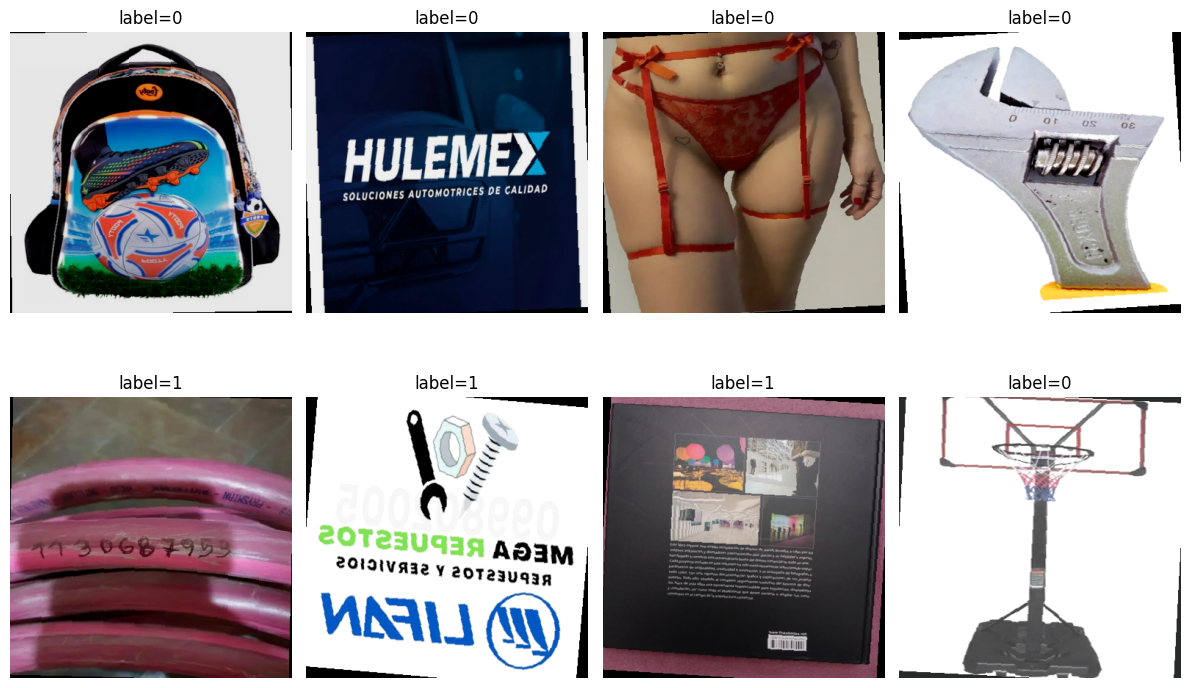

In [9]:
# ## 8. Visualización rápida de un batch
#
# Sirve para verificar que los paths y transformaciones funcionan.

def denormalize(img_tensor, mean, std):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return img_tensor.cpu() * std + mean


images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))
for i in range(min(8, len(images))):
    img = denormalize(images[i], imagenet_mean, imagenet_std).clamp(0, 1)
    img = img.permute(1, 2, 0).numpy()
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(f"label={int(labels[i].item())}")
    plt.axis("off")
plt.tight_layout()
plt.show()


In [10]:
# ## 9. Modelo EfficientNet-B0
#
# Usamos pesos preentrenados y reemplazamos la última capa por una salida binaria.

model = efficientnet_b0(weights=weights)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 1)
model = model.to(DEVICE)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1, bias=True)
)


In [11]:
# ## 10. Loss, optimizador y scheduler
#
# Usamos `pos_weight` suavizado porque el train tiene muchos más positivos que el test. Esto evita empujar demasiado al modelo a predecir positivo.

train_internal_df = train_full_df.iloc[train_idx]
num_pos = (train_internal_df["label"] == 1).sum()
num_neg = (train_internal_df["label"] == 0).sum()
pos_weight_value = np.sqrt(num_neg / max(num_pos, 1))
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(DEVICE)

print(f"num_pos={num_pos}, num_neg={num_neg}, pos_weight_suavizado={pos_weight_value:.3f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
)

num_pos=2550, num_neg=5950, pos_weight_suavizado=1.528


In [12]:
# ## 11. Funciones de entrenamiento y evaluación

def run_one_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_labels = []
    all_probs = []

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True).view(-1, 1)

        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

        probs = torch.sigmoid(logits).detach().cpu().numpy().ravel()
        y_true = labels.detach().cpu().numpy().ravel()

        total_loss += loss.item() * images.size(0)
        all_probs.extend(probs.tolist())
        all_labels.extend(y_true.tolist())

    avg_loss = total_loss / len(loader.dataset)
    all_labels = np.array(all_labels).astype(int)
    all_probs = np.array(all_probs)

    return avg_loss, all_labels, all_probs


def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        zero_division=0,
    )

    beta = 2
    if precision + recall == 0:
        f2 = 0.0
    else:
        f2 = (1 + beta**2) * precision * recall / ((beta**2 * precision) + recall)

    try:
        auc_pr = average_precision_score(y_true, y_prob)
    except Exception:
        auc_pr = np.nan

    try:
        auc_roc = roc_auc_score(y_true, y_prob)
    except Exception:
        auc_roc = np.nan

    cm = confusion_matrix(y_true, y_pred)

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "f2": f2,
        "auc_pr": auc_pr,
        "auc_roc": auc_roc,
        "cm": cm,
    }


In [13]:
# ## 12. Entrenamiento
#
# Se guarda el mejor modelo según `val_auc_pr`. Hay early stopping si no mejora durante `EARLY_STOPPING_PATIENCE` epochs.

best_auc_pr = -1
best_model_path = OUTPUT_DIR / "best_efficientnet_b0.pt"

history = []
epochs_without_improvement = 0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_y, train_p = run_one_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_y, val_p = run_one_epoch(model, val_loader, optimizer=None)

    train_metrics = compute_metrics(train_y, train_p, threshold=0.5)
    val_metrics = compute_metrics(val_y, val_p, threshold=0.5)

    scheduler.step(val_metrics["auc_pr"])

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_auc_pr": train_metrics["auc_pr"],
        "val_auc_pr": val_metrics["auc_pr"],
        "train_recall": train_metrics["recall"],
        "val_recall": val_metrics["recall"],
        "train_precision": train_metrics["precision"],
        "val_precision": val_metrics["precision"],
        "val_f2": val_metrics["f2"],
        "lr": optimizer.param_groups[0]["lr"],
    }
    history.append(row)

    print("-" * 80)
    print(f"Epoch {epoch}/{NUM_EPOCHS}")
    print(f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")
    print(
        f"val_auc_pr={val_metrics['auc_pr']:.4f} | "
        f"val_auc_roc={val_metrics['auc_roc']:.4f} | "
        f"val_precision={val_metrics['precision']:.4f} | "
        f"val_recall={val_metrics['recall']:.4f} | "
        f"val_f2={val_metrics['f2']:.4f}"
    )
    print("Confusion matrix val @ threshold=0.5:")
    print(val_metrics["cm"])

    if val_metrics["auc_pr"] > best_auc_pr:
        best_auc_pr = val_metrics["auc_pr"]
        epochs_without_improvement = 0
        torch.save({
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "val_auc_pr": float(best_auc_pr),
            "img_size": IMG_SIZE,
            "model_name": "efficientnet_b0",
            "threshold": None,
        }, best_model_path)
        print("Nuevo mejor modelo guardado en:", best_model_path)
    else:
        epochs_without_improvement += 1
        print(f"Sin mejora en val_auc_pr por {epochs_without_improvement} epoch(s).")
        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print("Early stopping activado.")
            break

history_df = pd.DataFrame(history)
history_path = OUTPUT_DIR / "training_history.csv"
history_df.to_csv(history_path, index=False)
print("Historial guardado en:", history_path)

--------------------------------------------------------------------------------
Epoch 1/6
train_loss=0.6092 | val_loss=0.5450
val_auc_pr=0.7026 | val_auc_roc=0.8481 | val_precision=0.6667 | val_recall=0.6978 | val_f2=0.6913
Confusion matrix val @ threshold=0.5:
[[893 157]
 [136 314]]
Nuevo mejor modelo guardado en: C:\git\tp_vp2\work\efficientnet_b0\best_efficientnet_b0.pt
--------------------------------------------------------------------------------
Epoch 2/6
train_loss=0.4914 | val_loss=0.5001
val_auc_pr=0.7450 | val_auc_roc=0.8769 | val_precision=0.6940 | val_recall=0.7156 | val_f2=0.7111
Confusion matrix val @ threshold=0.5:
[[908 142]
 [128 322]]
Nuevo mejor modelo guardado en: C:\git\tp_vp2\work\efficientnet_b0\best_efficientnet_b0.pt
--------------------------------------------------------------------------------
Epoch 3/6
train_loss=0.4284 | val_loss=0.4820
val_auc_pr=0.7709 | val_auc_roc=0.8866 | val_precision=0.7074 | val_recall=0.7467 | val_f2=0.7385
Confusion matrix val 

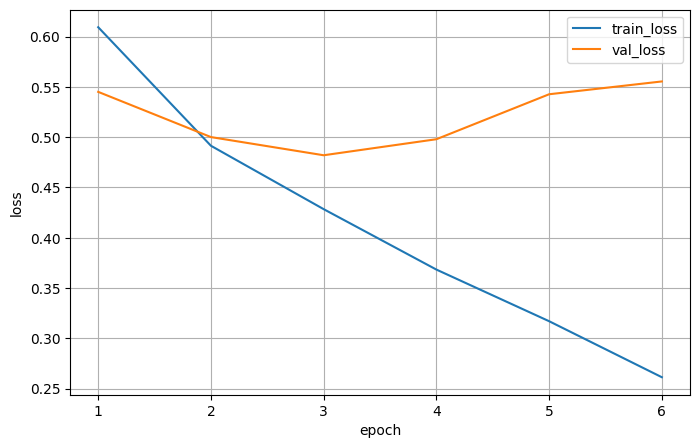

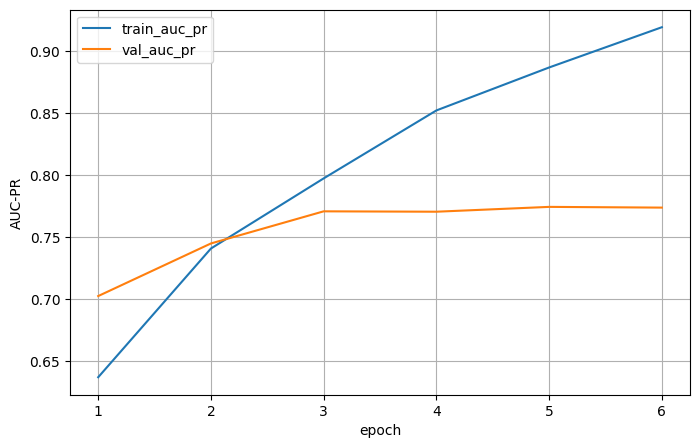

In [14]:
# ## 13. Curvas simples de entrenamiento

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_auc_pr"], label="train_auc_pr")
plt.plot(history_df["epoch"], history_df["val_auc_pr"], label="val_auc_pr")
plt.xlabel("epoch")
plt.ylabel("AUC-PR")
plt.legend()
plt.grid(True)
plt.show()

Mejor threshold en validación interna:
Criterio: max recall con precision >= 0.7
threshold    0.370000
precision    0.701681
recall       0.742222
f1           0.721382
f2           0.733743
Name: 32, dtype: float64


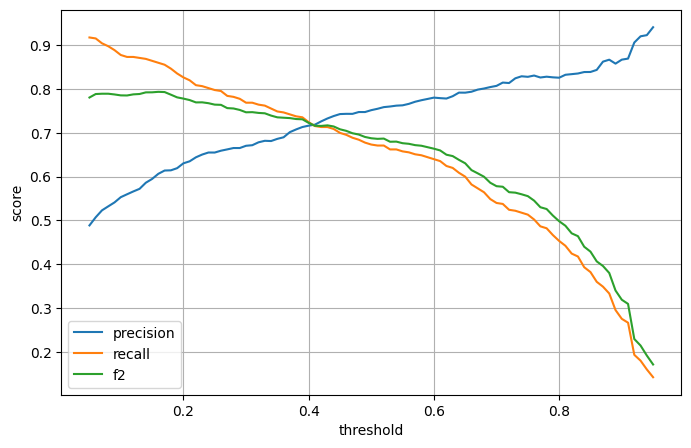

In [15]:
# ## 14. Buscar umbral óptimo en validación interna
#
# Priorizamos recall, pero solo entre thresholds con precision mínima aceptable.

checkpoint = torch.load(best_model_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

val_loss, val_y, val_p = run_one_epoch(model, val_loader, optimizer=None)

thresholds = np.linspace(0.05, 0.95, 91)
rows = []

for th in thresholds:
    m = compute_metrics(val_y, val_p, threshold=th)
    rows.append({
        "threshold": th,
        "precision": m["precision"],
        "recall": m["recall"],
        "f1": m["f1"],
        "f2": m["f2"],
    })

threshold_df = pd.DataFrame(rows)
threshold_path = OUTPUT_DIR / "threshold_search_val.csv"
threshold_df.to_csv(threshold_path, index=False)

candidates = threshold_df[threshold_df["precision"] >= MIN_PRECISION_FOR_THRESHOLD].copy()

if len(candidates) > 0:
    best_row = candidates.sort_values("recall", ascending=False).iloc[0]
    selection_criterion = f"max recall con precision >= {MIN_PRECISION_FOR_THRESHOLD}"
else:
    best_row = threshold_df.sort_values("f2", ascending=False).iloc[0]
    selection_criterion = "fallback: max F2 porque ningún threshold alcanzó la precision mínima"

BEST_THRESHOLD = float(best_row["threshold"])

print("Mejor threshold en validación interna:")
print("Criterio:", selection_criterion)
print(best_row)

torch.save({
    "model_state_dict": model.state_dict(),
    "epoch": checkpoint["epoch"],
    "val_auc_pr": checkpoint["val_auc_pr"],
    "img_size": IMG_SIZE,
    "model_name": "efficientnet_b0",
    "threshold": float(BEST_THRESHOLD),
}, best_model_path)

plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="recall")
plt.plot(threshold_df["threshold"], threshold_df["f2"], label="f2")
plt.xlabel("threshold")
plt.ylabel("score")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# ## 15. Evaluación final en test
#
# El test se usa al final, con el threshold elegido en validación.

test_loss, test_y, test_p = run_one_epoch(model, test_loader, optimizer=None)
test_metrics = compute_metrics(test_y, test_p, threshold=BEST_THRESHOLD)

print("=" * 80)
print("RESULTADOS TEST")
print("test_loss:", test_loss)
print("threshold usado:", BEST_THRESHOLD)
print("AUC-PR:", test_metrics["auc_pr"])
print("AUC-ROC:", test_metrics["auc_roc"])
print("Precision:", test_metrics["precision"])
print("Recall:", test_metrics["recall"])
print("F1:", test_metrics["f1"])
print("F2:", test_metrics["f2"])
print("Confusion matrix:")
print(test_metrics["cm"])

print("\nClassification report:")
print(classification_report(test_y, (test_p >= BEST_THRESHOLD).astype(int), zero_division=0))

test_results = test_df.copy()
test_results["prob_contact"] = test_p
test_results["score"] = test_p          # alias para schema estandarizado
test_results["pred"] = (test_p >= BEST_THRESHOLD).astype(int)
test_results["model_name"] = "efficientnet_b0"
test_results["error_type"] = "ok"
test_results.loc[(test_results["label"] == 0) & (test_results["pred"] == 1), "error_type"] = "false_positive"
test_results.loc[(test_results["label"] == 1) & (test_results["pred"] == 0), "error_type"] = "false_negative"

test_results_path = OUTPUT_DIR / "test_predictions.csv"
test_results.to_csv(test_results_path, index=False)
print("Predicciones test guardadas en:", test_results_path)

RESULTADOS TEST
test_loss: 0.2826572513182958
threshold usado: 0.36999999999999994
AUC-PR: 0.20767122380000505
AUC-ROC: 0.8800836690080673
Precision: 0.1440329218106996
Recall: 0.7526881720430108
F1: 0.24179620034542315
F2: 0.40792540792540793
Confusion matrix:
[[2491  416]
 [  23   70]]

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      2907
           1       0.14      0.75      0.24        93

    accuracy                           0.85      3000
   macro avg       0.57      0.80      0.58      3000
weighted avg       0.96      0.85      0.90      3000

Predicciones test guardadas en: C:\git\tp_vp2\work\efficientnet_b0\test_predictions.csv


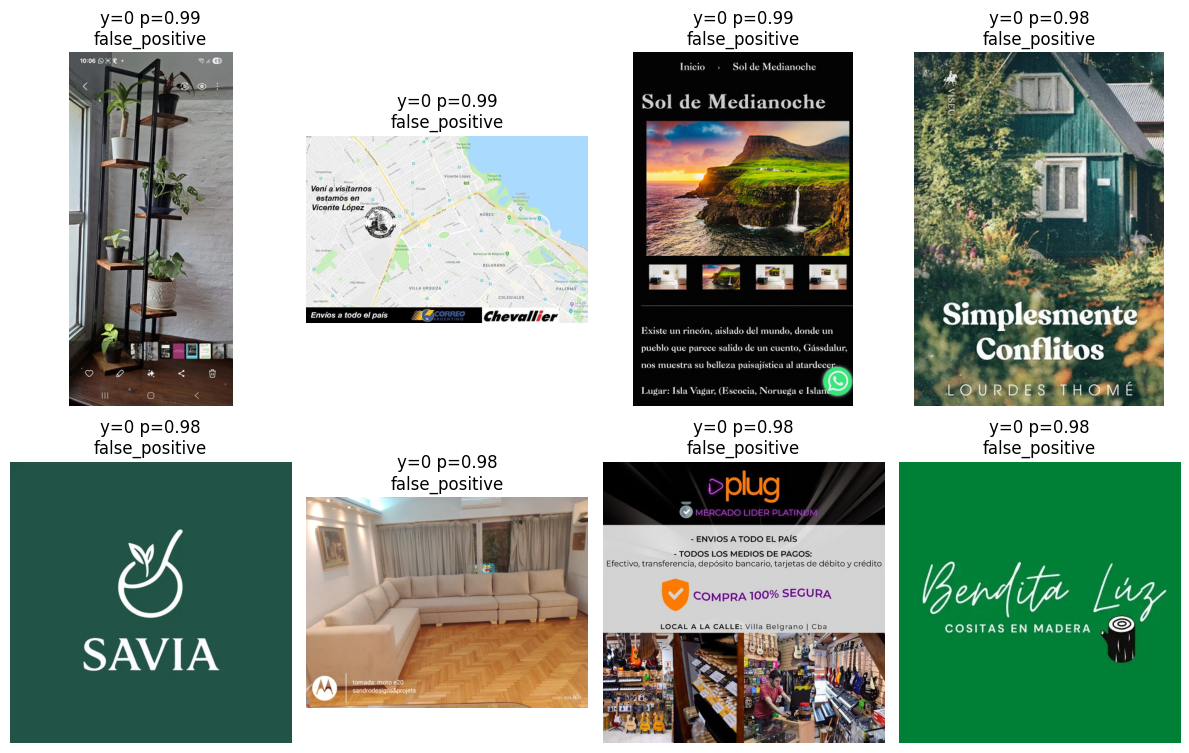

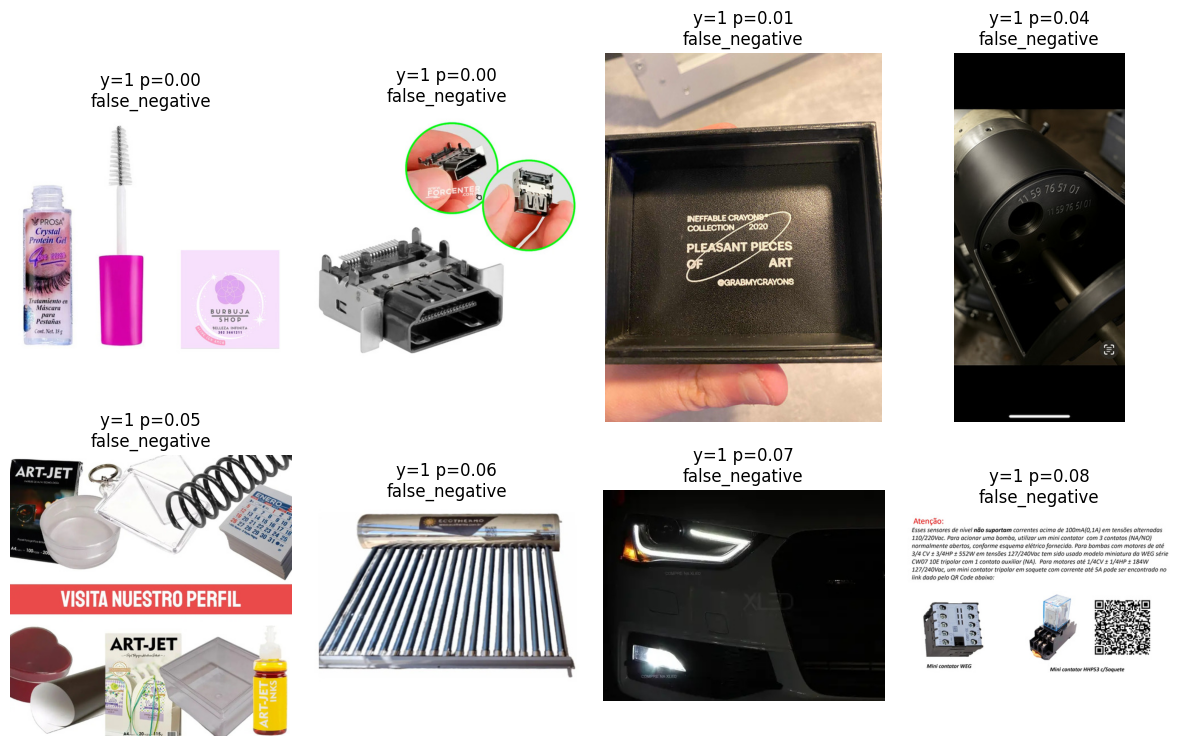

In [17]:
# ## 16. Mirar ejemplos de errores

def show_examples(results_df, split_root, error_type, n=8):
    subset = results_df[results_df["error_type"] == error_type].copy()
    if subset.empty:
        print(f"No hay ejemplos de {error_type}")
        return

    subset = subset.sort_values("prob_contact", ascending=(error_type == "false_negative")).head(n)

    plt.figure(figsize=(12, 8))
    for i, (_, row) in enumerate(subset.iterrows()):
        image_path = Path(str(row["image_path"]))
        img_path = Path(split_root) / image_path
        if not img_path.exists():
            img_path_alt = Path(split_root).parent / image_path
            if img_path_alt.exists():
                img_path = img_path_alt
        img = Image.open(img_path).convert("RGB")
        plt.subplot(2, 4, i + 1)
        plt.imshow(img)
        plt.title(f"y={row['label']} p={row['prob_contact']:.2f}\n{error_type}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()


show_examples(test_results, DATASET_DIR / "test", "false_positive", n=8)
show_examples(test_results, DATASET_DIR / "test", "false_negative", n=8)

In [18]:
# ## 17. Función simple de inferencia para una imagen nueva

def predict_image(image_path, threshold=BEST_THRESHOLD):
    model.eval()
    image = Image.open(image_path).convert("RGB")
    x = val_transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logit = model(x)
        prob = torch.sigmoid(logit).item()

    pred = int(prob >= threshold)
    return {
        "image_path": str(image_path),
        "prob_contact": prob,
        "pred": pred,
        "threshold": threshold,
    }

In [19]:
# Ejemplo de inferencia sobre una imagen del test local:
# predict_image(DATASET_DIR / "test" / "images" / "test_000000.jpg")
